In [1]:
!pip install pingouin

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\emdzd\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


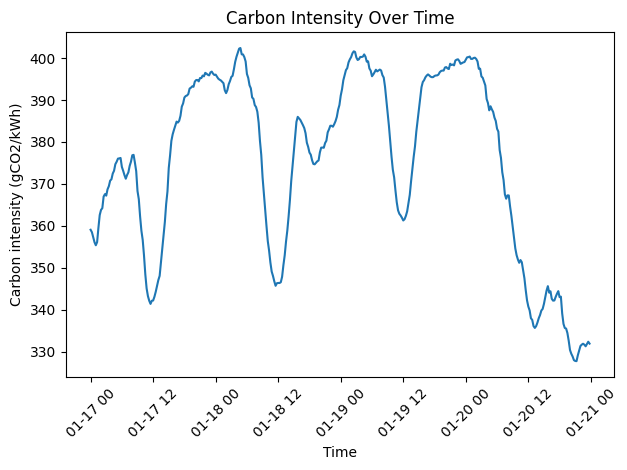

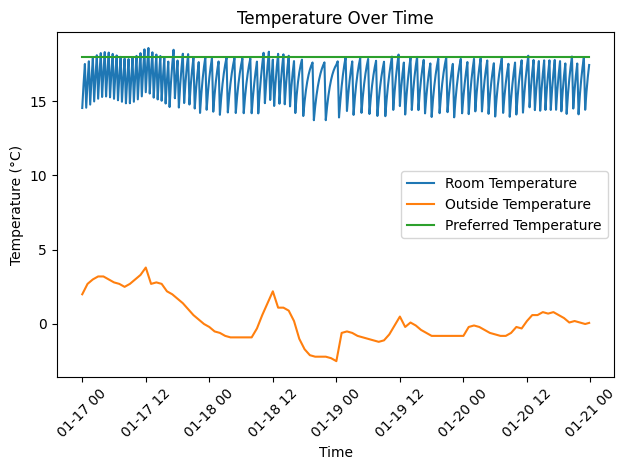

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/bang_18.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp")

df = df[
        (df["timestamp"] >= "2025-01-17") &
        (df["timestamp"] < "2025-01-21")
    ]

plt.figure()
plt.plot(df["timestamp"], df["carbon_intensity_gco2_per_kwh"])
plt.xlabel("Time")
plt.ylabel("Carbon intensity (gCO2/kWh)")
plt.title("Carbon Intensity Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(df["timestamp"], df["room_temprature"], label="Room Temperature")
plt.plot(df["timestamp"], df["outside_temperature_C"], label="Outside Temperature")
plt.plot(df["timestamp"], df["preferred_room_temperature_C"], label="Preferred Temperature")

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Temperature Over Time")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

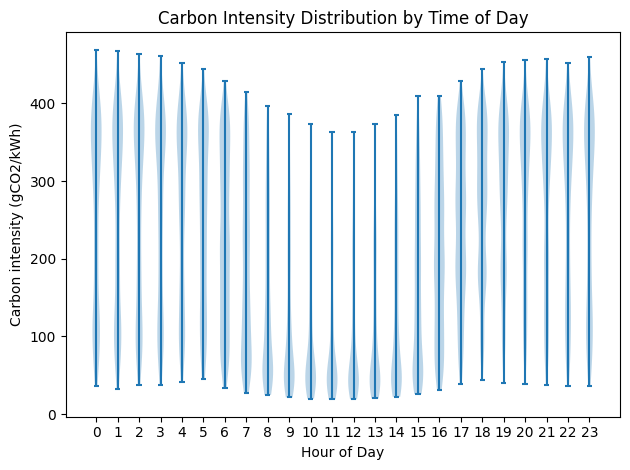

In [3]:

df = pd.read_csv("data/room_alg_co2_18.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])

df["hour"] = df["timestamp"].dt.hour + df["timestamp"].dt.minute / 60

#df["hour_bin"] = df["hour"].round().astype(int)
df["hour_bin"] = df["hour"].floordiv(1).astype(int)

plt.figure()

data = [
    df[df["hour_bin"] == h]["carbon_intensity_gco2_per_kwh"].dropna()
    for h in range(24)
]

plt.violinplot(data, positions=range(24))

plt.xlabel("Hour of Day")
plt.ylabel("Carbon intensity (gCO2/kWh)")
plt.title("Carbon Intensity Distribution by Time of Day")

plt.xticks(range(24), range(24))
plt.tight_layout()
plt.show()



assuming CO₂ (g)=heating_wattage_W /​ 1000 × carbon_intensity × Δt (hours)

data\bang_18.csv
data\room_alg_co2_18.csv
data\room_alg_no_co2_18.csv


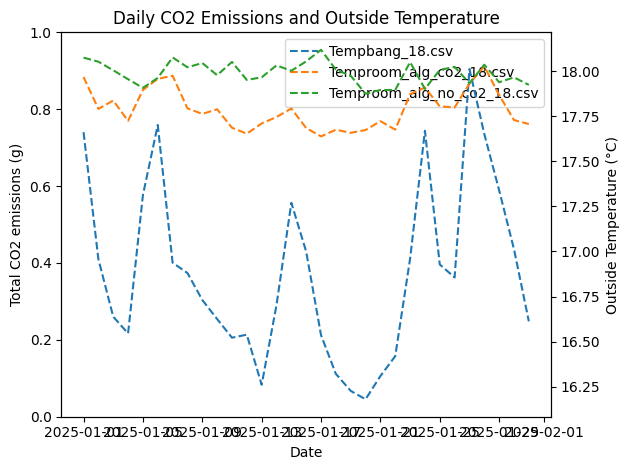

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

file_paths = glob.glob("data/*.csv")

fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

for file in file_paths:
    print(file)
    if file == "bang_18.csv":
        continue
    df = pd.read_csv(file)

    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp")

    df = df[
        (df["timestamp"] >= "2025-01-01") &
        (df["timestamp"] < "2025-02-01")
    ]

    df["dt_hours"] = df["timestamp"].diff().dt.total_seconds() / 3600

    df["energy_kWh"] = df["heating_wattage_W"] / 1000 * df["dt_hours"]
    df["carbon_g"] = df["energy_kWh"] * df["carbon_intensity_gco2_per_kwh"]

    df["date"] = df["timestamp"].dt.date

    daily_carbon = df.groupby("date")["carbon_g"].sum()


    label = os.path.basename(file)

    #ax1.plot(daily_carbon.index, daily_carbon.values, label=f"CO2 {label}")
    print(df.groupby("date")["room_temprature"])
    daily_temp = df.groupby("date")["room_temprature"].mean()
    ax2.plot(daily_temp.index, daily_temp.values, linestyle="--", label=f"Temp{label}")
ax1.set_xlabel("Date")
ax1.set_ylabel("Total CO2 emissions (g)")
ax2.set_ylabel("Outside Temperature (°C)")

plt.title("Daily CO2 Emissions and Outside Temperature")

plt.xticks(rotation=45)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2)

plt.tight_layout()
plt.show()

In [5]:

df = pd.read_csv("data/room_alg_co2_18.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")

df["dt_hours"] = df["timestamp"].diff().dt.total_seconds() / 3600
df["dt_hours"] = df["dt_hours"].bfill()

df["energy_kWh"] = df["heating_wattage_W"] / 1000 * df["dt_hours"]

df["carbon_g"] = df["energy_kWh"] * df["carbon_intensity_gco2_per_kwh"]

df["date"] = df["timestamp"].dt.date
daily = df.groupby("date")["carbon_g"].sum().reset_index()

daily["date"] = pd.to_datetime(daily["date"])
daily = daily.set_index("date")

monthly_stats = daily["carbon_g"].resample("M").agg(["mean", "std"])

print(monthly_stats)

                   mean          std
date                                
2025-01-31  4647.828998  2180.523376
2025-02-28  4700.830448  1902.505325
2025-03-31  3691.706800  1477.402749
2025-04-30  2192.746665   943.669436
2025-05-31   823.799178   394.084120
2025-06-30   319.794278   269.964236
2025-07-31   246.485098   173.835155
2025-08-31   363.881685   306.086130
2025-09-30   857.010197   768.230539
2025-10-31  1228.733694   607.725658
2025-11-30  2804.613191  1602.103309
2025-12-31  2969.174974  1344.423686
2026-01-31     9.823013          NaN


C:\Users\emdzd\AppData\Local\Temp\ipykernel_24176\3726633320.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_stats = daily["carbon_g"].resample("M").agg(["mean", "std"])


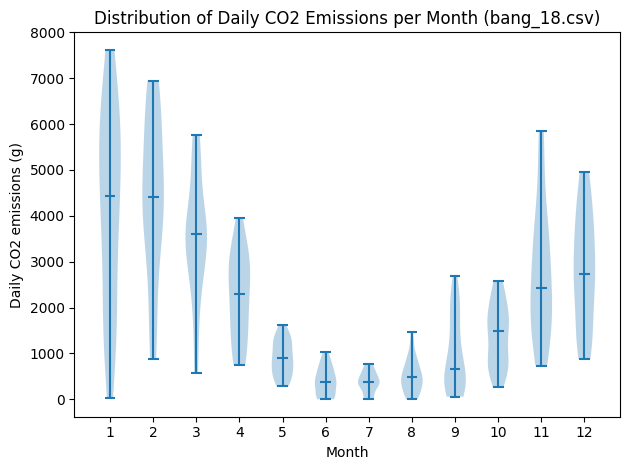

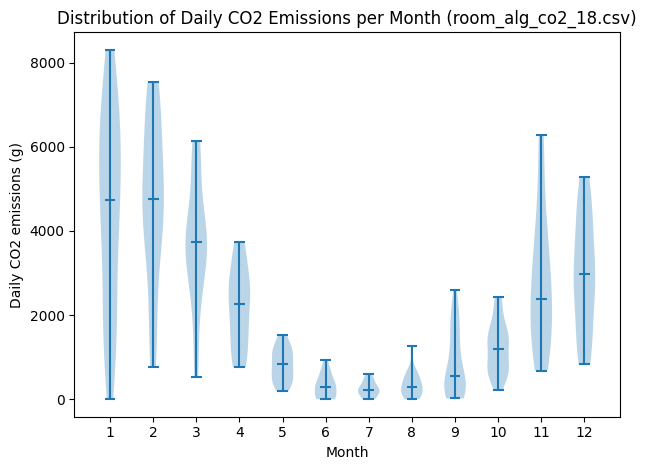

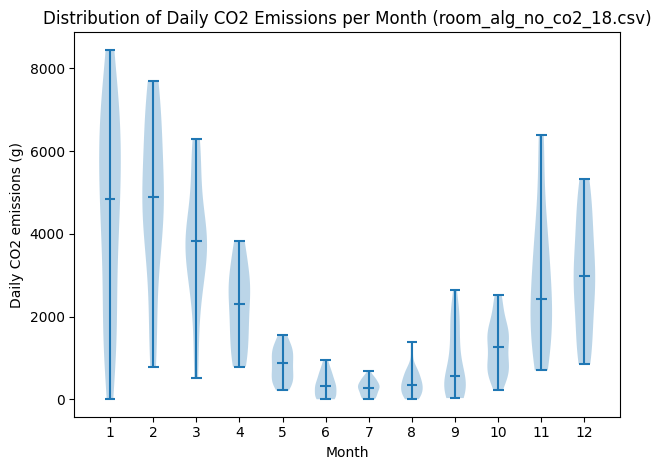

In [6]:

file_paths = glob.glob("data/*.csv")


for file in file_paths:
    df = pd.read_csv(file)

    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp")




    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp")

    df["dt_hours"] = df["timestamp"].diff().dt.total_seconds() / 3600
    df["dt_hours"] = df["dt_hours"].bfill()

    df["energy_kWh"] = df["heating_wattage_W"] / 1000 * df["dt_hours"]

    df["carbon_g"] = df["energy_kWh"] * df["carbon_intensity_gco2_per_kwh"]

    df["date"] = df["timestamp"].dt.date
    daily = df.groupby("date")["carbon_g"].sum().reset_index()

    daily["date"] = pd.to_datetime(daily["date"])
    daily["month"] = daily["date"].dt.month

    data = [
        daily[daily["month"] == m]["carbon_g"].values
        for m in range(1, 13)
    ]

    plt.figure()
    plt.violinplot(data, positions=range(1, 13), showmedians=True)

    plt.xlabel("Month")
    plt.ylabel("Daily CO2 emissions (g)")
    plt.title("Distribution of Daily CO2 Emissions per Month (" + os.path.basename(file) + ")")

    plt.xticks(range(1, 13), range(1, 13))
    plt.tight_layout()
    plt.show()

In [7]:
import glob
import pandas as pd
import os

all_data = []

file_paths = glob.glob("data/*.csv")

for file in file_paths:
    df = pd.read_csv(file)

    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp")

    df["dt_hours"] = df["timestamp"].diff().dt.total_seconds() / 3600
    df["dt_hours"] = df["dt_hours"].bfill()

    df["energy_kWh"] = df["heating_wattage_W"] / 1000 * df["dt_hours"]
    df["carbon_g"] = df["energy_kWh"] * df["carbon_intensity_gco2_per_kwh"]

    df["date"] = df["timestamp"].dt.date

    daily = df.groupby("date")["carbon_g"].sum().reset_index()

    daily["date"] = pd.to_datetime(daily["date"])
    daily["month"] = daily["date"].dt.month

    daily["algorithm"] = os.path.basename(file)

    all_data.append(daily)

df_all = pd.concat(all_data, ignore_index=True)

In [8]:
import statsmodels.formula.api as smf

df_all["month"] = df_all["month"].astype("category")
df_all["algorithm"] = df_all["algorithm"].astype("category")

model = smf.mixedlm(
    "carbon_g ~ algorithm * month",
    df_all,
    groups=df_all["date"]
)

result = model.fit()
print(result.summary())

                                Mixed Linear Model Regression Results
Model:                            MixedLM                Dependent Variable:                carbon_g  
No. Observations:                 1098                   Method:                            REML      
No. Groups:                       366                    Scale:                             7021.2968 
Min. group size:                  3                      Log-Likelihood:                    -7404.8491
Max. group size:                  3                      Converged:                         Yes       
Mean group size:                  3.0                                                                 
------------------------------------------------------------------------------------------------------
                                                   Coef.    Std.Err.    z    P>|z|   [0.025    0.975] 
------------------------------------------------------------------------------------------------------
Int

In [9]:
import pingouin as pg

results = []

for m in df_all["month"].unique():
    subset = df_all[df_all["month"] == m]

    res = pg.pairwise_tests(
        data=subset,
        dv="carbon_g",
        within="algorithm",
        subject="date",
        padjust="bonf"
    )

    res["month"] = m
    results.append(res)

posthoc = pd.concat(results)

posthoc_summary = posthoc[["month", "A", "B", "p_unc"]]

posthoc_summary = posthoc_summary.rename(columns={
    "A": "Algorithm 1",
    "B": "Algorithm 2",
    "p_unc": "p-value"
})

posthoc_summary["Significant"] = posthoc_summary["p-value"].apply(lambda p: "true" if p < 0.05 else "false")

posthoc_summary = posthoc_summary.sort_values(by="month").reset_index(drop=True)



In [10]:
import pandas as pd
from IPython.display import display, HTML

months = sorted(posthoc_summary["month"].unique())
pairs = posthoc_summary[["Algorithm 1", "Algorithm 2"]].drop_duplicates()
pairs["pair"] = pairs["Algorithm 1"] + " vs " + pairs["Algorithm 2"]

lookup = {}
for _, row in posthoc_summary.iterrows():
    key = (row["Algorithm 1"] + " vs " + row["Algorithm 2"], row["month"])
    lookup[key] = row["p-value"]

month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

html = """
<style>
  .htable { border-collapse: collapse; font-size: 13px; }
  .htable th { font-size: 12px; color: #666; padding: 6px 10px; text-align: center;
               border-bottom: 1px solid #ddd; white-space: nowrap; }
  .htable th.row-header { text-align: left; }
  .htable td { padding: 7px 10px; text-align: center; border: 1px solid #ddd;
               font-size: 12px; white-space: nowrap; }
  .htable td.algo-label { text-align: left; font-weight: 500; background: #f9f9f9; }
  .sig    { background: #C0DD97; color: #3B6D11; border-radius: 4px; padding: 2px 10px; }
  .nonsig { background: #F7C1C1; color: #A32D2D; border-radius: 4px; padding: 2px 10px; }
</style>
<div style="margin-bottom:10px; font-size:12px; display:flex; gap:16px;">
  <span><span style="display:inline-block;width:12px;height:12px;background:#C0DD97;border-radius:3px;margin-right:5px;"></span>p &lt; 0.05 (true)</span>
  <span><span style="display:inline-block;width:12px;height:12px;background:#F7C1C1;border-radius:3px;margin-right:5px;"></span>p &ge; 0.05 (false)</span>
</div>
<table class="htable">
  <thead><tr>
    <th class="row-header">Pair</th>
"""

for m in months:
    label = month_names[m - 1] if isinstance(m, int) and 1 <= m <= 12 else str(m)
    html += f"    <th>{label}</th>\n"

html += "  </tr></thead>\n<tbody>\n"

for _, row in pairs.iterrows():
    pair = row["pair"]
    html += f'  <tr><td class="algo-label">{pair}</td>\n'
    for m in months:
        p = lookup.get((pair, m))
        if p is None:
            html += '    <td><span style="color:#aaa">—</span></td>\n'
        else:
            sig = p < 0.05
            cls = "sig" if sig else "nonsig"
            label = "true" if sig else "false"
            html += f'    <td><span class="{cls}">{label}</span></td>\n'
    html += "  </tr>\n"

html += "</tbody></table>"

display(HTML(html))

Pair,1,2,3,4,5,6,7,8,9,10,11,12
bang_18.csv vs room_alg_co2_18.csv,true,true,true,true,true,true,true,true,true,true,false,true
bang_18.csv vs room_alg_no_co2_18.csv,true,true,true,false,true,true,true,true,true,true,true,true
room_alg_co2_18.csv vs room_alg_no_co2_18.csv,true,true,true,true,true,true,true,true,true,true,true,true


In [12]:
import glob
import os
 
import numpy as np
import pandas as pd
import pingouin as pg
import statsmodels.formula.api as smf
from scipy import stats

def load_algorithm_files(pattern: str = "data/*.csv") -> pd.DataFrame:
    file_paths = glob.glob(pattern)
    if not file_paths:
        raise FileNotFoundError(f"No CSV files found matching: {pattern}")
 
    all_data = []
 
    for file in file_paths:
        df = pd.read_csv(file)
        df["timestamp"] = pd.to_datetime(df["timestamp"])
        df = df.sort_values("timestamp").reset_index(drop=True)
 
        df["dt_hours"] = df["timestamp"].diff().dt.total_seconds() / 3600
        df["dt_hours"] = df["dt_hours"].bfill()
 
        df["energy_kWh"] = df["heating_wattage_W"] / 1000 * df["dt_hours"]
        df["carbon_g"]   = df["energy_kWh"] * df["carbon_intensity_gco2_per_kwh"]
 
        df["date"] = df["timestamp"].dt.date
 
        # Daily aggregation: sum carbon, keep mean covariates for regression
        agg = {"carbon_g": "sum", "carbon_intensity_gco2_per_kwh": "mean"}
        if "outdoor_temp_C" in df.columns:
            agg["outdoor_temp_C"] = "mean"
 
        daily = df.groupby("date").agg(agg).reset_index()
        daily["date"]      = pd.to_datetime(daily["date"])
        daily["month"]     = daily["date"].dt.month
        daily["algorithm"] = os.path.basename(file)
 
        all_data.append(daily)
 
    df_all = pd.concat(all_data, ignore_index=True)
    print(f"Loaded {len(file_paths)} algorithm file(s).")
    print(f"Total algorithm-day rows: {len(df_all)}")
    print(f"Algorithms: {sorted(df_all['algorithm'].unique())}")
    print(f"Date range: {df_all['date'].min().date()} → {df_all['date'].max().date()}\n")
    return df_all

def add_residuals(df_all: pd.DataFrame) -> pd.DataFrame:
    covariates = ["carbon_intensity_gco2_per_kwh"]
    if "outdoor_temp_C" in df_all.columns:
        covariates.append("outdoor_temp_C")
 
    cov_terms = " + ".join(covariates)
    formula   = f"carbon_g ~ C(algorithm) + {cov_terms}"
 
    model = smf.ols(formula, data=df_all).fit()
    df_all["residual"] = model.resid
 
    print("OLS model summary (confounder regression):")
    print(model.summary().tables[0])
    print(f"R² = {model.rsquared:.3f}  |  Adj-R² = {model.rsquared_adj:.3f}\n")
    return df_all

In [ ]:
def run_pairwise_tests(df_all: pd.DataFrame) -> pd.DataFrame:
    algorithms = sorted(df_all["algorithm"].unique())
    months     = sorted(df_all["month"].unique())
    results    = []
 
    for month in months:
        subset = df_all[df_all["month"] == month]
 
        wide = subset.pivot_table(index="date", columns="algorithm",
                                   values="residual")
 
        for i, algo_a in enumerate(algorithms):
            for algo_b in algorithms[i + 1:]:
 
                pair = wide[[algo_a, algo_b]].dropna()
 
                if len(pair) < 5:
                    continue
 
                a_vals = pair[algo_a].values
                b_vals = pair[algo_b].values
 
                stat, p_unc = stats.wilcoxon(a_vals, b_vals,
                                              alternative="two-sided")
 
                n    = len(pair)
                r_rb = 1 - (2 * stat) / (n * (n + 1))
 
                results.append({
                    "month":       month,
                    "Algorithm 1": algo_a,
                    "Algorithm 2": algo_b,
                    "n_days":      n,
                    "W_stat":      stat,
                    "p_unc":       p_unc,
                    "r_rb":        round(r_rb, 3),
                })
 
    if not results:
        raise RuntimeError("No valid paired comparisons found. "
                           "Check that algorithms share overlapping dates.")
 
    posthoc = pd.DataFrame(results)
 
    posthoc["n_tests"]  = posthoc.groupby("month")["p_unc"].transform("count")
    posthoc["p_bonf"]   = (posthoc["p_unc"] * posthoc["n_tests"]).clip(upper=1.0)
    posthoc["p_unc"]    = posthoc["p_unc"].round(4)
    posthoc["p_bonf"]   = posthoc["p_bonf"].round(4)
    posthoc["sig_bonf"] = posthoc["p_bonf"] < 0.05
 
    posthoc = posthoc.sort_values(["month", "Algorithm 1", "Algorithm 2"])
    posthoc = posthoc.reset_index(drop=True)
 
    return posthoc[["month", "Algorithm 1", "Algorithm 2",
                    "n_days", "W_stat", "p_unc", "p_bonf",
                    "r_rb", "sig_bonf"]]

def print_summary(posthoc: pd.DataFrame) -> None:
    print("=" * 72)
    print("PAIRWISE WILCOXON TESTS ON OLS RESIDUALS (Bonferroni-corrected)")
    print("=" * 72)
 
    for month, grp in posthoc.groupby("month"):
        print(f"\n── Month {month} ──")
        print(grp.drop(columns="month").to_string(index=False))
 
    sig = posthoc[posthoc["sig_bonf"]]
    print("\n" + "=" * 72)
    if sig.empty:
        print("No significant differences after Bonferroni correction.")
    else:
        print(f"{len(sig)} significant pair(s) after correction:")
        for _, row in sig.iterrows():
            direction = ("worse" if row["r_rb"] < 0 else "better")
            print(f"  Month {row['month']:>2}: {row['Algorithm 1']} vs "
                  f"{row['Algorithm 2']}  |  p_bonf={row['p_bonf']:.4f}  "
                  f"|  r_rb={row['r_rb']:.3f} ({row['Algorithm 1']} "
                  f"{direction})")
    print("=" * 72)

In [19]:
df_all  = load_algorithm_files("data/*.csv")
df_all  = add_residuals(df_all)
posthoc = run_pairwise_tests(df_all)
print_summary(posthoc)
 


Loaded 3 algorithm file(s).
Total algorithm-day rows: 1098
Algorithms: ['bang_18.csv', 'room_alg_co2_18.csv', 'room_alg_no_co2_18.csv']
Date range: 2025-01-01 → 2026-01-01

OLS model summary (confounder regression):
                            OLS Regression Results                            
Dep. Variable:               carbon_g   R-squared:                       0.527
Model:                            OLS   Adj. R-squared:                  0.526
Method:                 Least Squares   F-statistic:                     406.0
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          3.36e-177
Time:                        13:19:51   Log-Likelihood:                -9451.3
No. Observations:                1098   AIC:                         1.891e+04
Df Residuals:                    1094   BIC:                         1.893e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                    